# Functional API

La API funcional de keras permite la construccion de modelos con arquitectura diversa. Modelos con multiples modulos de entrada, multiples modedulos de salida o con estructura tipo grafo son construibles con la misma.

In [11]:
from keras import Input
from keras.layers import Dense

input_tensor = Input(shape=(32,))    # Tensor de tamaño 32 como entrada
dense = Dense(32, activation='relu') # Funcion (capa) que recive tensor y devuelve otro (tamaño 32)
output_tensor = dense(input_tensor)

print('input_tensor', input_tensor)
print('output_tensor', output_tensor)

input_tensor <KerasTensor shape=(None, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_20>
output_tensor <KerasTensor shape=(None, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_21>


Construir modelos con este tipo de estructura es necesario para procesamiento paralelo (ejemplo [modulos Inception](https://arxiv.org/abs/1409.4842.)) y para enviar la misma salida a distintos nodos (ejemplo [conexiones residuales](https://arxiv.org/abs/1512.03385)).

A continuacion se muestran ejemplos de un modelo `Sequential` simple y su equivalente con la API funcional.

In [ ]:
from keras import Input
from keras.layers import Dense
from keras.models import Sequential, Model

# Modelo secuencial
seq_model = Sequential()
seq_model.add(Dense(32, activation='relu', input_shape=(64,)))
seq_model.add(Dense(32, activation='relu'))
seq_model.add(Dense(10, activation='softmax'))
seq_model.summary()

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,466 (13.54 KB)

 Trainable params: 3,466 (13.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Equivalente funcional
input_tensor = Input(shape=(64,))
x = Dense(32, activation='relu')(input_tensor)
x = Dense(32, activation='relu')(x)
output_tensor = Dense(10, activation='softmax')(x)
model = Model(input_tensor, output_tensor)
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,466 (13.54 KB)

 Trainable params: 3,466 (13.54 KB)

 Non-trainable params: 0 (0.00 B)

Keras encuentra todas las capas relacionadas entre `input_tensor` y `output_tensor`. Juntandolas para obtener una estructura de datos tipo grafo (un modelo).

Si se llega a pasar estructuras no relacionadas se obtiene un error de ejecucion.

In [18]:
unrelated_input = Input(shape=(32,))
bad_model =  Model(unrelated_input, output_tensor)

ValueError: `inputs` not connected to `outputs`

Para compilar, entrenar o evaluar la API es la misma que para con `Sequential`.

In [23]:
from keras.optimizers import RMSprop
from numpy.random import random

model.compile(optimizer=RMSprop(), loss='categorical_crossentropy')

x_train = random((1000, 64))
y_train = random((1000, 10))

model.fit(x_train, y_train, epochs=10, batch_size=128)

score = model.evaluate(x_train, y_train)

Epoch 1/10


I0000 00:00:1770076239.496098 2289495 service.cc:152] XLA service 0x7fc034004800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770076239.496116 2289495 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2026-02-02 20:50:39.569530: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770076239.683309 2289495 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/8 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 11.9748

I0000 00:00:1770076240.134878 2289495 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 11.8832
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.7174 
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.9520 
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.5058 
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.5679 
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14.9022 
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.4212 
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.0315 
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.9208 
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21.5025 
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 22.4050


# Modelos con multiples entradas

A continuacion se muestra un modelo de respuesta a preguntas que recibe 2 textos:
1. Texto de referencia.
2. Pregunta.

Codifica cada texto mediante un embeddingm, pasa por una LSTM, se concatena la salida de los 2 y se genera una respuesta mediante una capa Densa.

![Modelo con multiples inputs](images/7.1.multiple-inputs.png)

In [ ]:
from keras import Input
from keras.models import Model
from keras.layers import LSTM, Dense, Embedding, Concatenate
from keras.optimizers import RMSprop

text_vocabulary_size = 10000
question_vocabulary_size = 10000
answer_vocabulary_size = 500

# Entrada de texto
# Como entrada una secuencia de enteros de largo variable
text_input = Input(shape=(None,), dtype='int32', name='text')
# Codificar la entrada en vectores de tamaño 64
embedded_text = Embedding(text_vocabulary_size, 64)(text_input)
# Codifica los vectores en un unico vector
encoded_text = LSTM(32)(embedded_text)

# Entrada de pregunta
# Como entrada una secuencia de enteros de largo 32
question_input = Input(shape=(32,), dtype='int32', name='question')
# Codificar la entrada en vectores de tamaño 64
embedded_question = Embedding(question_vocabulary_size, 32)(question_input)
# Codifica los vectores en un unico vector
encoded_question = LSTM(16)(embedded_question)

# Tramos final con union
# Concatenar ambas preguntas
concatenated = Concatenate(axis=-1)([encoded_text, encoded_question])
# Clasificador softmax
answer = Dense(answer_vocabulary_size, activation='softmax')(concatenated)

# Modelo
model = Model([text_input, question_input], answer)
model.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['acc'])
model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question            │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 64)  │    640,000 │ text[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 32, 32)    │    320,000 │ question[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │     12,416 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 16)        │      3,136 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48)        │          0 │ lstm_2[0][0],     │
│ (Concatenate)       │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 500)       │     24,500 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,000,052 (3.81 MB)

 Trainable params: 1,000,052 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

El ingreso de los datos se puede hacer de dos formas:
1. Con una lista de areglos de entero numpy.
2. Con un diccionario que mapee nombres de entrada a arreglos numpy (solo disponible si al crear las capas de entrada se les asignaron nombres).

In [14]:
from numpy.random import randint
from keras.utils import to_categorical

num_samples = 1000
max_length_text = 100
max_length_question = 32

text = randint(1, text_vocabulary_size, size=(num_samples,max_length_text))
question = randint(1, question_vocabulary_size, size=(num_samples,max_length_question))
labels = randint(0, answer_vocabulary_size, size=(num_samples,)) # Etiquetas
answers = to_categorical(labels, answer_vocabulary_size) # Codificacion One-Hot

# Opcion 1: lista de arreglos
model.fit([text, question], answers, epochs=10, batch_size=128)

# Opcion 2: diccionario de arreglos
model.fit({'text':text, 'question':question}, answers, epochs=10, batch_size=128)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.0036 - loss: 6.2458
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.0058 - loss: 6.1662
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.0076 - loss: 6.1062
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.0039 - loss: 6.0678
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.0091 - loss: 6.0362
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.0045 - loss: 6.0301
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.0083 - loss: 6.0151
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.0069 - loss: 6.0110   
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.0096 - loss: 6.0094
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.0104 - loss: 6.0129
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.0054 - loss: 6.0080
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.0068 - loss: 5.9879   
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0

# Modelos con multiples salidas

Para ejemplificar este caso se construye un modelo que recibe una serie de posteos en redes sociales de una persona y predice atributos de la misma, tales como edad, genero y nivel de ingresos.

![Modelo con multiples outputs](images/7.1.multiple-outputs.png)

In [1]:
from keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Embedding
from keras import Input
from keras.models import Model

vocabulary_size = 50000
num_income_groups = 10

# Entrada un arreglo de una cantidad indefinida de vectores de enteros
posts_input = Input(shape=(None,), dtype='int32', name='posts')
embedded_posts = Embedding(vocabulary_size, 256)(posts_input)
x = Conv1D(128, 5, activation='relu')(embedded_posts)
x = MaxPooling1D(5)(x)
x = Conv1D(256, 5, activation='relu')(x)
x = Conv1D(256, 5, activation='relu')(x)
x = MaxPooling1D(5)(x)
x = Conv1D(256, 5, activation='relu')(x)
x = Conv1D(256, 5, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(128, activation='relu')(x)

# Salidas del modelo (cada una con su nombre)
age_prediction = Dense(1, name='age')(x)
income_prediction = Dense(num_income_groups, activation='softmax', name='income')(x)
gender_prediction = Dense(1, activation='sigmoid', name='gender')(x)

# Modelo (salidas declaradas en forma de lista)
model = Model(posts_input, [age_prediction, income_prediction, gender_prediction])
model.summary()

2026-02-03 19:08:07.431139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770156487.449030 2643785 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770156487.454477 2643785 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770156487.468867 2643785 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770156487.468886 2643785 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770156487.468887 2643785 computation_placer.cc:177] computation placer alr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ posts (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │ 12,800,000 │ posts[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, None, 128) │    163,968 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, None, 128) │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, None, 256) │    164,096 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, None, 256) │    327,936 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, None, 256) │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, None, 256) │    327,936 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, None, 256) │    327,936 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d_4[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        129 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ income (Dense)      │ (None, 10)        │      1,290 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        129 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,146,316 (53.96 MB)

 Trainable params: 14,146,316 (53.96 MB)

 Non-trainable params: 0 (0.00 B)

Para entrenar la red es necesario especificar distintas funciones de error para cada salida. No obstante, el descenso gradiente requiere que estos se lleven a un solo valor escalar. 

Hay que combinar los distintos errores en uno solo. La forma mas sencilla de hacer esto es sumarlos.

Keras permite especificarlo de dos formas:
1. Indicando el error para cada output en forma de lista.
2. Indicando el error para cada output en forma de diccionario.

In [2]:
from keras.optimizers import RMSprop

# Opcion 1: Compilar con lista de errores
model.compile(
    optimizer=RMSprop(), 
    loss=['mse', 'categorical_crossentropy', 'binary_crossentropy']
)

# Opcion 2: compilar con diccionario de errores (solo disponible 
# si se le asignaron nombres a las capas de salida)
model.compile(
    optimizer=RMSprop(),
    loss={
        'age': 'mse',
        'income': 'categorical_crossentropy',
        'gender': 'binary_crossentropy'
    }
)

Contribuciones de error desbalanceadas probocan que el modelo se optimize mas para una tarea a expensas de las demas. Para solventar esa situacion se pueden asignar niveles de importancia a cada error en su contribucion para el error final. 

Util si los distintos errores se mueven en escalas distintas. Por ejemplo *MSE* para regresion de edad tipicamente toma valores entre 3 y 5, mientras que la *entropia crusada* usada para la clasificacion de genero puede ser tan bajo como 0.1. Para balancear esta situacion se puede asignar un peso de 10 a *entropia cruzada* y un peso de 0.25 a *MSE*.

In [3]:
# Con lista
model.compile(
    optimizer=RMSprop(), 
    loss=['mse', 'categorical_crossentropy', 'binary_crossentropy'],
    loss_weights=[0.25, 1., 10.]
)

# Con diccionario
model.compile(
    optimizer=RMSprop(),
    loss={
        'age': 'mse',
        'income': 'categorical_crossentropy',
        'gender': 'binary_crossentropy'
    },
    loss_weights={
        'age': 0.25,
        'income': 1.,
        'gender': 10.
    }
)

Al realizar el entrenamiento se especifican los valores que corresponden a cada salida. Denuebo se puede hacer de dos formas:
1. Con una lista de arreglos.
2. Con un diccionario de arreglos.

In [4]:
from numpy.random import randint
from keras.utils import to_categorical

num_samples=1000
max_length_post=2000

posts = randint(1, vocabulary_size, size=(num_samples,max_length_post))
age_targets = randint(0, 150, num_samples)  # Vector escalar
income_targets_labels = randint(0, num_income_groups, size=(num_samples,)) # Etiquetas
income_targets = to_categorical(income_targets_labels, num_income_groups) # Vector de vectores One-Hot
gender_targets = randint(0, 2, num_samples) # Vector binario

# Opcion 1: lista
model.fit(
    posts, 
    [age_targets, income_targets, gender_targets],
    epochs=10,
    batch_size=64
)

# Opcion 2 diccionario
model.fit(
    posts, 
    {
        'age':age_targets, 
        'income':income_targets, 
        'gender':gender_targets
    },
    epochs=10,
    batch_size=64
)

Epoch 1/10


I0000 00:00:1770156501.026758 2644043 service.cc:152] XLA service 0x7f362400d290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770156501.026804 2644043 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2026-02-03 19:08:21.146946: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770156502.000446 2644043 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/16 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - age_loss: 9118.9453 - gender_loss: 0.7002 - income_loss: 2.3361 - loss: 2289.0742 

I0000 00:00:1770156513.854706 2644043 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 631ms/step - age_loss: 5649.9780 - gender_loss: 3.5451 - income_loss: 9.5173 - loss: 1459.2313
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - age_loss: 1852.0150 - gender_loss: 1.5309 - income_loss: 5.6866 - loss: 484.5529
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - age_loss: 2101.7769 - gender_loss: 1.3736 - income_loss: 2.6614 - loss: 542.3426
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - age_loss: 1462.5504 - gender_loss: 1.2869 - income_loss: 2.5662 - loss: 381.6031
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - age_loss: 981.5619 - gender_loss: 1.3649 - income_loss: 2.4861 - loss: 260.8744
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - age_loss: 749.7345 - gender_loss: 1.2912 - income_loss: 2.5802 - loss: 203.1331
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - age_loss: 852.7839 - gender_loss: 1.2499 - income_loss: 2.5397 - loss: 227.4933
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - age_loss: 1223.0417 

# Grafos aciclicos de capas

Tambien se pueden implementar redes con topologias internas complejas. En concreto se pueden armar redes en forma de grafos aciclicos. El termino *aciclico* es importante ya que denota que no puede haber ciclos dentro de la red. Un tensor X no puede generar una salida que luego sea usada como su propia entrada.

Las conexiones recurrentes solo pueden manejarse dentro de la definicion interna de una capa.

Muchos componentes comunes de aprendizaje automatico son implementados con grafos. Entre estos destacan: el *modulo inception*, las *conexiones residuales*.

## Modulo inception

Se trata de una arquitectura de red para el procesamiento convolucional de datos. Paraleliza cadenas de convoluciones $1x1$ y $SxS$ para ayudar a aprender caracteristicas espaciales y caracteristicas de cada canal. 

A continuacion se muestra un diagrama y su respectiva implementacion en keras del modulo inception V3.

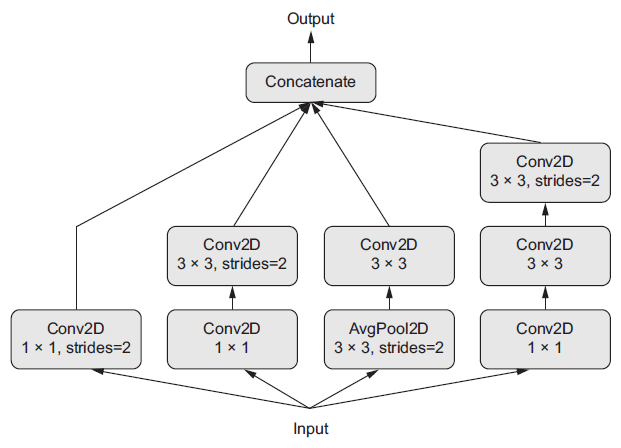

In [6]:
from keras.layers import Conv2D, AveragePooling2D, Concatenate
from keras import Input, Model

# Tensor 4D (batch, x, y, chan)
width = 32
high = 32
channels = 3
input = Input(shape=(width, high, channels), dtype='int32')

branch_a = Conv2D(128, 1, activation='relu', strides=2, name='branch_a')(input)

branch_b = Conv2D(128, 1, activation='relu', name='branch_b')(input)
branch_b = Conv2D(128, 3, activation='relu', strides=2, padding='same', name='branch_b_1')(branch_b)

branch_c = AveragePooling2D(3, strides=2, padding='same', name='branch_c')(input)
branch_c = Conv2D(128, 3, activation='relu', padding='same', name='branch_c_1')(branch_c)

branch_d = Conv2D(128, 1, activation='relu', name='branch_d')(input)
branch_d = Conv2D(128, 3, activation='relu', padding='same', name='branch_d_1')(branch_d)
branch_d = Conv2D(128, 3, activation='relu', strides=2, padding='same', name='branch_d_2')(branch_d)

concatenated = Concatenate(axis=-1)([branch_a, branch_b, branch_c, branch_d])

# Modelo
model = Model(input, concatenated)
model.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_d (Conv2D)   │ (None, 32, 32,    │        512 │ input_layer_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_b (Conv2D)   │ (None, 32, 32,    │        512 │ input_layer_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_c            │ (None, 16, 16, 3) │          0 │ input_layer_1[0]… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_d_1 (Conv2D) │ (None, 32, 32,    │    147,584 │ branch_d[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_a (Conv2D)   │ (None, 16, 16,    │        512 │ input_layer_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_b_1 (Conv2D) │ (None, 16, 16,    │    147,584 │ branch_b[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_c_1 (Conv2D) │ (None, 16, 16,    │      3,584 │ branch_c[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_d_2 (Conv2D) │ (None, 16, 16,    │    147,584 │ branch_d_1[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ branch_a[0][0],   │
│ (Concatenate)       │ 512)              │            │ branch_b_1[0][0], │
│                     │                   │            │ branch_c_1[0][0], │
│                     │                   │            │ branch_d_2[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 447,872 (1.71 MB)

 Trainable params: 447,872 (1.71 MB)

 Non-trainable params: 0 (0.00 B)

## Conexiones residuales

Las conexiones residuales atacan 2 problemas que surgen en modelos de gran escala:
1. Desvanecimiento de gradiente.
2. Cuellos de botella de representacion.

Consisten en hacer que la salida de una capa temprana sea la entrada de una capa tardia. Similar a un atajo en el recorrido de la red.

En vez de concatenar la salida antigua con la mas reciente estas se suman. Se asume que ambas conexiones mantienen el mismo tamaño. Si los tamaños son distintos se puede usar una transformacion lineal para redimensionar la salida mas temprana.

Añadir conexiones residuales en cualquier modelo con mas de 10 capas suele ser beneficioso.

A continuacion se muestra un ejemplo de una conexion residual donde no es necesario redimensionar los datos.

In [5]:
from keras.layers import  Conv2D, Add
from keras import Input, Model

# Tensor 4D (batch, x, y, chan)
width = 32
high = 32
channels = 128
x = Input(shape=(width, high, channels), dtype='int32')
y = Conv2D(128, 3, activation='relu', padding='same')(x)
y = Conv2D(128, 3, activation='relu', padding='same')(y)
y = Conv2D(128, 3, activation='relu', padding='same')(y)

# Se añade la entrada original al vector de salida
y = Add()([y, x])

# Modelo
model = Model(x, y)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    147,584 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32,    │          0 │ conv2d_8[0][0],   │
│                     │ 128)              │            │ input_layer[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 442,752 (1.69 MB)

 Trainable params: 442,752 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

A continuacion se muestra un ejemplo de una conexion residual donde debido a dimensiones discordantes en los mapas de caracteristicas es necesario redimensionar los datos.

In [8]:
from keras.layers import  Conv2D, Add, MaxPooling2D
from keras import Input, Model

# Tensor 4D (batch, x, y, chan)
width = 32
high = 32
channels = 128
x = Input(shape=(width, high, channels), dtype='int32')

y = Conv2D(128, 3, activation='relu', padding='same')(x)
y = Conv2D(128, 3, activation='relu', padding='same')(y)
y = MaxPooling2D(2, strides=2)(y)

# Convolucion 1x1 para reducir el tamaño de x hasta y
residual = Conv2D(128, 1, strides=2)(x)

# Se añade la entrada original al vector de salida
y = Add()([y, residual])

# Modelo
model = Model(x, y)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │    147,584 │ input_layer_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_12[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │     16,512 │ input_layer_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 16, 16,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │ conv2d_14[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 311,680 (1.19 MB)

 Trainable params: 311,680 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

# Pesos compartidos

La API funcional permite que una misma capa sea usada mas de una ves, permitiendo que esta reuse los mismos pesos cada que es llamada.

En el siguiente ejemplo se muestra un modelo que compara la similiritud semantica entre 2 oraciones. La similiritud semantica es una relacion bidireccional por lo que no tiene sentido entrenar una capa LSTM para cada una. Se usa una capa LSTM que se entrenara con los pesos de ambas entradas al mismo tiempo. Este patron se lo conoce como *Siamese LSTM* o *Shared LSTM*.

In [11]:
from numpy.random import randint, random

# Datos nabos
samples = 1000
left_data = random((samples, 128, 1))
right_data = random((samples, 128, 1))
targets = randint(0, 2, (1000,))

In [12]:
from keras.layers import LSTM, Dense, Concatenate
from keras import Input
from keras.models import Model

# Instanciar LSTM (1 sola vez)
lstm = LSTM(32)

# Rama izquierda
left_input = Input(shape=(None, 128))
left_output = lstm(left_input)

# Rama derecha
right_input = Input(shape=(None, 128))
right_output = lstm(right_input)

# Clasificador
merged = Concatenate(-1)([left_output, right_output])
predictions = Dense(1, activation='sigmoid')(merged)

# Modelo
model = Model([left_input, right_input], predictions)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, None, 128) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, None, 128) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 32)        │     20,608 │ input_layer_8[0]… │
│                     │                   │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 64)        │          0 │ lstm_4[0][0],     │
│ (Concatenate)       │                   │            │ lstm_4[1][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ concatenate_4[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,673 (80.75 KB)

 Trainable params: 20,673 (80.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from keras.optimizers import RMSprop

# Compilar y entrenar
model.compile(optimizer=RMSprop(), loss='binary_crossentropy', metrics=['acc'])
model.fit([left_data, right_data], targets, batch_size=128, epochs=10)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.4906 - loss: 0.6938
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.4767 - loss: 0.6935
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.4774 - loss: 0.6935
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.4937 - loss: 0.6935
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.5164 - loss: 0.6932
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.4776 - loss: 0.6937
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.5034 - loss: 0.6934
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.5085 - loss: 0.6933
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.5269 - loss: 0.6931
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.4947 - loss: 0.6932


# Modelos como capas

En la API funcional se puede emplear modelos como capas, capas que reciben un tensor de entrada y producen un tensor de salida.
```
y = model(x)
```
Si el modelo tiene multiples tensores de entrada o salida este debe ser llamado con una lista de tensores.
```
y1, y2 = model([x1, x2])
```
Cada llamada usa los pesos correspondientes al modelo enlazado.

A continuacion se muestra un ejemplo practico donde se construye un modelo de vision que usa camaras dobles como entrada: Dos camaras parallelas a unos pocos centimetros una de otra. El objetivo es que el modelo perciba la profundidad.

No se necesitan dos modelos distintos para extraer las caracteristicas visuales de cada camara antes de compararlas. Se puede usar el mismo modelo con los mismos pesos para extraer las caracteristicas mas relevantes. Es un *Siamese Vision Model* que comparte la base convolucional entre distintas entradas.

In [ ]:
from keras.layers import Concatenate
from keras.applications import Xception
from keras import Input, Model

# Modelo con la base convolucional de Xception
xception_base = Xception(weights=None, include_top=False)

# Entradas
left_input = Input(shape=(250,250,3))
right_input = Input(shape=(250,250,3))

# Procesamiento de cada rama con el mismo modelo
left_features = xception_base(left_input)
right_features = xception_base(right_input)

# Union
merged_features = Concatenate(axis=-1)([left_features, right_features])

# Modelo final
final_model = Model([left_input, right_input], merged_features)
final_model.summary()

I0000 00:00:1770564862.098981  105779 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11534 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 250, 250,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 250, 250,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception            │ (None, 8, 8,      │ 20,861,480 │ input_layer_1[0]… │
│ (Functional)        │ 2048)             │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8,      │          0 │ xception[0][0],   │
│ (Concatenate)       │ 4096)             │            │ xception[1][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)